# Load Libraries

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sbn
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

# Load Files

In [2]:
train_data = pd.read_csv("../input/digit-recognizer/train.csv")
test_data = pd.read_csv("../input/digit-recognizer/test.csv")
train_data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
#shape
print(f"train shape: {train_data.shape}, test shape:{test_data.shape}")

train shape: (42000, 785), test shape:(28000, 784)


In [4]:
#dtypes of target
train_data.label.dtypes

dtype('int64')

In [5]:
#Unique Target values
train_data.label.unique()

array([1, 0, 4, 7, 3, 5, 8, 9, 2, 6])

In [6]:
#Total Digits in target
train_data.label.unique().shape[0]

10

In [7]:
#dtypes of features
train_data.iloc[0, 1:].dtypes

dtype('int64')

In [8]:
#pixel values of the First digit
train_data.iloc[0, 1:].to_numpy()

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0, 188, 255,  94,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0, 191, 250, 253,  93,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   

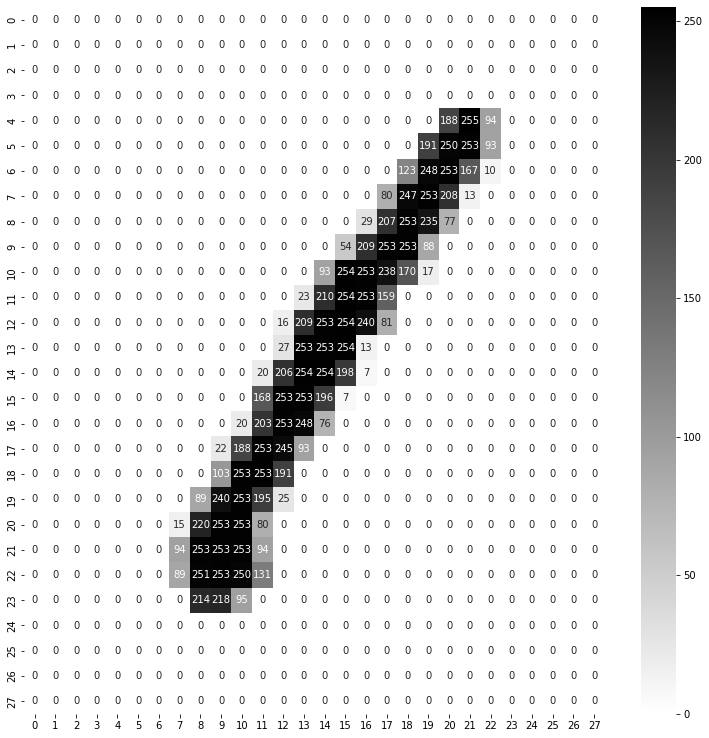

In [9]:
#Above digit looks like
plt.figure(figsize=(13, 13))
sbn.heatmap(train_data.iloc[0, 1:].to_numpy().reshape(28, 28), fmt='d', cmap='binary', annot=True)
plt.show()

In [10]:
#max and min pixel values of the First digit
print("min pixel value", train_data.iloc[0, 1:].to_numpy().min())
print("max pixel value", train_data.iloc[0, 1:].to_numpy().max())

min pixel value 0
max pixel value 255


In [11]:
#Train Test Split
x_train, x_test, y_train, y_test = train_test_split(train_data.drop('label', axis=1), train_data.label, test_size=0.01, random_state=10)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((41580, 784), (420, 784), (41580,), (420,))

In [12]:
#standardize and Convert To Tensors
x_train = torch.tensor(x_train.to_numpy())
y_train = torch.tensor(y_train.to_numpy())
x_test = torch.tensor(x_test.to_numpy())
y_test = torch.tensor(y_test.to_numpy())

In [13]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cpu'

# Model Building, Training and Evaluation

In [14]:
#Lets define the model
class NeuralNetwork(nn.Module):
    def __init__(self, in_, out_):
        super(NeuralNetwork, self).__init__()
        self.layers = nn.Sequential(
        nn.Linear(in_, 1024),
        nn.ReLU(),
        nn.Linear(1024, 512),
        nn.ReLU(),
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Linear(128, out_),
        nn.Softmax()
        )
    def forward(self, x):
        return self.layers(x.type(torch.float))

In [15]:
model = NeuralNetwork(784, 10)
model.to(DEVICE)
model

NeuralNetwork(
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=1024, bias=True)
    (1): ReLU()
    (2): Linear(in_features=1024, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Linear(in_features=128, out_features=10, bias=True)
    (9): Softmax(dim=None)
  )
)

In [16]:
#Loss and Optimizer
Criterion_loss = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

In [17]:
#Train the Model
EPOCHS = 1000
loss_ = []
acc_ = []
val_loss_ = []
val_acc_ =[]
for epoch in range(EPOCHS):
    optimizer.zero_grad()
    train_pred = model(x_train.to(DEVICE))
    test_pred = model(x_test.to(DEVICE))
    loss = Criterion_loss(train_pred, y_train.to(DEVICE))
    val_loss = Criterion_loss(test_pred, y_test.to(DEVICE))
    loss_.append(loss.item())
    val_loss_.append(val_loss.item())
    loss.backward()
    optimizer.step()
    accuracy = torch.mean((torch.argmax(train_pred, 1)==y_train).float()).item()
    val_accuracy = torch.mean((torch.argmax(test_pred, 1)==y_test).float()).item()
    acc_.append(accuracy)
    val_acc_.append(val_accuracy)

/opt/conda/lib/python3.7/site-packages/torch/nn/modules/container.py:141: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  input = module(input)


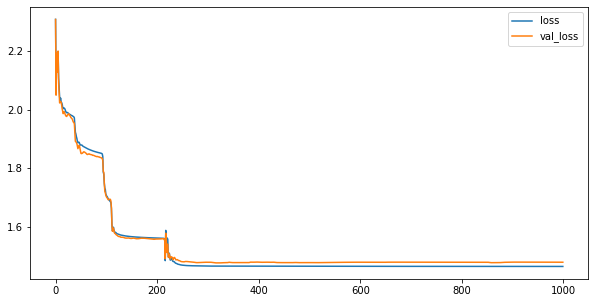

In [18]:
#plot the Train and Validation loss
pd.DataFrame(data = {'loss': loss_, "val_loss":val_loss_}).plot(figsize=(10,5))
plt.show()

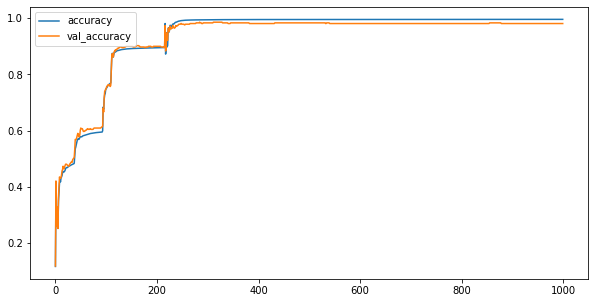

In [19]:
#plot the Train and Validation accuracy
pd.DataFrame(data = {'accuracy': acc_, "val_accuracy":val_acc_}).plot(figsize=(10,5))
plt.show()

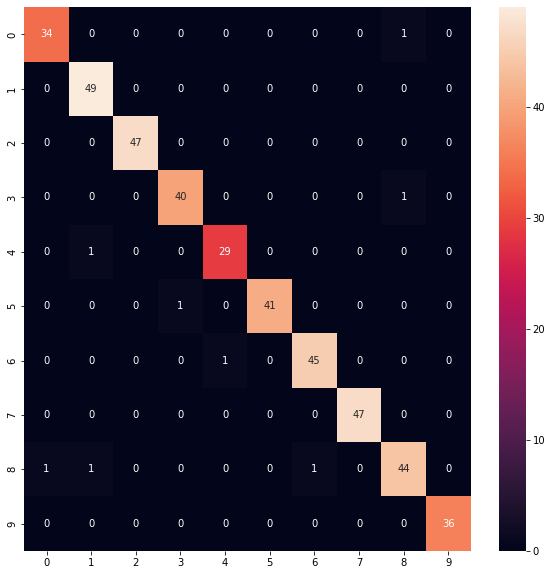

In [20]:
#Confusion matrix
with torch.no_grad():
    val_pred = model(x_test)
    pred = torch.argmax(val_pred, 1).cpu().numpy()
    target = y_test.cpu().numpy()
cm = confusion_matrix(target, pred)
plt.figure(figsize=(10,10))
sbn.heatmap(cm, annot=True, fmt='d')
plt.show()

# Submision to kaggle

In [21]:
with torch.no_grad():
    test_pred = torch.argmax(model(torch.tensor(test_data.to_numpy())), 1).cpu().numpy()
ImageId = []
for i in range(len(test_pred)):
    ImageId.append(i+1)

/opt/conda/lib/python3.7/site-packages/torch/nn/modules/container.py:141: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  input = module(input)


In [22]:
test_data['ImageId']=ImageId
test_data['Label']=test_pred
test_data[['ImageId', 'Label']].to_csv("Submission.csv", index=False)